<a href="https://colab.research.google.com/github/gabrielaespanapalacios/talentotecthG706/blob/master/Campistas_Ejemplo1ASC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# aprendizaje supervisado

es como aprender con un maestro. En este enfoque, el modelo se entrena utilizando un conjunto de datos que incluye tanto las entradas (características) como las salidas correctas (etiquetas). El objetivo es que el modelo aprenda a mapear las entradas a las salidas correctas para poder hacer predicciones precisas sobre datos nuevos.

## Ejemplo de clasidficación

Imagina que quieres crear un modelo que pueda distinguir entre fotos de perros y gatos. Tienes un conjunto de fotos, cada una etiquetada como "perro" o "gato". Usando este conjunto de datos etiquetado, el modelo aprende a reconocer patrones en las imágenes que corresponden a cada categoría.

In [ ]:
# Importamos la librería TensorFlow Datasets
# Esta librería nos permite usar datasets listos para IA (como gatos vs perros)
import tensorflow_datasets as tfds

# Cargamos el dataset "cats_vs_dogs"
# Este dataset ya viene con imágenes y etiquetas (0 = gato, 1 = perro)
dataset, info = tfds.load(

    'cats_vs_dogs',  # Nombre del dataset que queremos usar

    # Dividimos el dataset en dos partes:
    # - 80% para entrenar el modelo
    # - 20% para validar (probar si aprendió bien)
    split=['train[:80%]', 'train[80%:]'],

    # Esto hace que los datos se entreguen como:
    # (imagen, etiqueta)
    # Ejemplo: (foto de gato, 0)
    as_supervised=True,

    # Esto devuelve información adicional del dataset
    # (número de imágenes, clases, etc.)
    with_info=True
)

# Aquí se separan los datos en:
# train_ds → datos para entrenar
# val_ds → datos para validar
train_ds, val_ds = dataset

☝️Estamos descargando un conjunto de imágenes ya organizadas, donde cada imagen tiene una etiqueta que dice si es gato o perro. Además, dividimos los datos en dos partes: una para que el modelo aprenda y otra para evaluarlo

In [ ]:
# Importamos TensorFlow
# Nos permite trabajar con imágenes, modelos y procesamiento de datos
import tensorflow as tf

# Definimos el tamaño al que vamos a ajustar todas las imágenes
# (150x150 pixeles)
IMG_SIZE = (150,150)

# Creamos una función para procesar cada imagen del dataset
def format_image(image, label):

    # Redimensionamos la imagen al tamaño definido (150x150)
    # Esto es necesario porque todas las imágenes deben tener el mismo tamaño
    image = tf.image.resize(image, IMG_SIZE)

    # Normalizamos los valores de los pixeles
    # Pasamos de rango [0,255] → [0,1]
    # Esto ayuda a que el modelo aprenda mejor
    image = image / 255.0

    # Retornamos la imagen procesada junto con su etiqueta (gato o perro)
    return image, label


# Aplicamos la función a todo el dataset de entrenamiento
# .map() → aplica la función a cada imagen
# .batch(32) → agrupa las imágenes en lotes de 32 (más eficiente)
train_ds = train_ds.map(format_image).batch(32)

# Hacemos lo mismo para el dataset de validación
val_ds = val_ds.map(format_image).batch(32)

☝️Aquí estamos preparando las imágenes para que el modelo pueda entenderlas.
Las ajustamos al mismo tamaño, las convertimos a números más manejables y las organizamos en grupos para entrenar más rápido

In [ ]:
# Importamos las capas (layers) y el tipo de modelo (models)
# layers → bloques de la red neuronal
# models → estructura del modelo
from tensorflow.keras import layers, models

# Creamos un modelo secuencial
# Esto significa que las capas van una después de otra (en orden)
model = models.Sequential([

    # 🧠 CAPA 1: Convolucional
    # Detecta patrones básicos como bordes, formas, texturas
    layers.Conv2D(
        32,              # Número de filtros (qué tantas características aprende)
        (3,3),           # Tamaño del filtro (ventana que recorre la imagen)
        activation='relu',  # Función de activación (introduce no linealidad)
        input_shape=(150,150,3)  # Tamaño de entrada: imagen RGB (alto, ancho, canales)
    ),

    # 📉 CAPA 2: Pooling
    # Reduce el tamaño de la imagen para hacer el modelo más eficiente
    layers.MaxPooling2D(2,2),

    # 🧠 CAPA 3: Convolucional (más profunda)
    # Aprende características más complejas
    layers.Conv2D(64, (3,3), activation='relu'),

    # 📉 CAPA 4: Pooling
    layers.MaxPooling2D(2,2),

    # 🔄 CAPA 5: Flatten
    # Convierte la imagen en un vector (lista de números)
    # Necesario para conectarla con capas densas
    layers.Flatten(),

    # 🧠 CAPA 6: Densa (neuronal)
    # Aprende combinaciones de características
    layers.Dense(64, activation='relu'),

    # 🎯 CAPA FINAL: Salida
    # 1 neurona porque es clasificación binaria (gato o perro)
    # sigmoid → da un valor entre 0 y 1 (probabilidad)
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


☝️El modelo primero mira la imagen y detecta formas simples, luego formas más complejas, después resume toda la información y finalmente toma una decisión: gato o perro

In [ ]:
# Compilamos el modelo
# Aquí definimos CÓMO va a aprender

model.compile(

    # optimizer → método que ajusta los pesos del modelo
    # 'adam' es uno de los más usados porque es rápido y eficiente
    optimizer='adam',

    # loss → función de error
    # mide qué tan equivocadas son las predicciones del modelo
    # 'binary_crossentropy' se usa para clasificación binaria (gato vs perro)
    loss='binary_crossentropy',

    # metrics → métricas para evaluar el rendimiento
    # 'accuracy' = porcentaje de aciertos
    metrics=['accuracy']
)


# Entrenamos el modelo
# Aquí el modelo empieza a aprender de los datos

model.fit(

    train_ds,  # dataset de entrenamiento (donde aprende)

    epochs=5,  # número de veces que recorre todo el dataset
               # (más epochs = más aprendizaje, pero cuidado con sobreajuste)

    validation_data=val_ds  # dataset de validación
                            # sirve para ver si el modelo generaliza bien
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.6785 - loss: 0.5977 - val_accuracy: 0.7496 - val_loss: 0.5120
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.7889 - loss: 0.4468 - val_accuracy: 0.7769 - val_loss: 0.4771
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.8657 - loss: 0.3135 - val_accuracy: 0.7629 - val_loss: 0.5562
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.9253 - loss: 0.1863 - val_accuracy: 0.7023 - val_loss: 0.8129
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.9503 - loss: 0.1329 - val_accuracy: 0.7479 - val_loss: 0.8862


☝️Aquí le decimos al modelo cómo aprender, cómo medir sus errores y luego lo ponemos a practicar varias veces con los datos hasta que mejore

In [ ]:
# Recorremos el dataset de validación (val_ds)
# .take(1) significa que solo tomamos 1 lote (batch) de datos
for image, label in val_ds.take(1):

    # image → contiene varias imágenes (por ejemplo 32 si usaste batch(32))
    # label → contiene las etiquetas correspondientes

    # Seleccionamos una imagen específica del lote
    # [1] significa la segunda imagen (posición 1)
    sample_image = image[1]

    # Seleccionamos la etiqueta de esa misma imagen
    sample_label = label[1]

☝️Aquí estamos tomando una imagen del conjunto de prueba junto con su etiqueta real para ver si el modelo la puede clasificar correctamente.

In [ ]:
# Importamos numpy (útil para trabajar con arreglos numéricos)
import numpy as np

# Hacemos la predicción con el modelo
# tf.expand_dims → agrega una dimensión extra
# porque el modelo espera un lote (batch), no una sola imagen
# Convierte: (150,150,3) → (1,150,150,3)
prediction = model.predict(tf.expand_dims(sample_image, axis=0))

# Mostramos el valor numérico de la predicción
# Será un número entre 0 y 1 (probabilidad)
print("Predicción:", prediction)

# Interpretamos el resultado
# Si es mayor a 0.5 → perro
# Si es menor o igual → gato
if prediction[0] > 0.5:
    print("🐶 Es un PERRO")
else:
    print("🐱 Es un GATO")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
Predicción: [[0.01325376]]
🐱 Es un GATO


☝️Aquí el modelo analiza la imagen y devuelve un número entre 0 y 1.
Si el número es alto, es perro; si es bajo, es gato

In [ ]:
print("Etiqueta real:", sample_label.numpy())

Etiqueta real: 0


☝️Aquí estamos viendo la respuesta correcta del dataset para comparar si el modelo acertó o se equivocó

En este dataset:

0 → 🐱 gato

1 → 🐶 perro

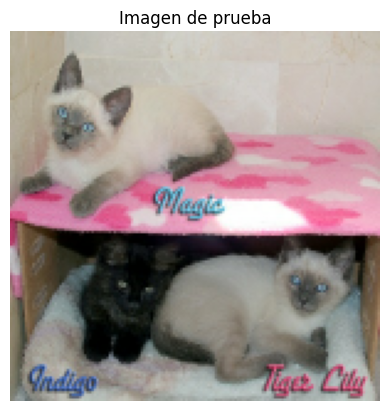

Predicción: GATO 🐱


In [ ]:
# Importamos matplotlib para mostrar imágenes y gráficos
import matplotlib.pyplot as plt

# Mostramos la imagen que estamos evaluando
plt.imshow(sample_image)

# Título de la imagen
plt.title("Imagen de prueba")

# Quitamos los ejes (para que se vea más limpio)
plt.axis('off')

# Mostramos la imagen en pantalla
plt.show()


# Ahora mostramos la predicción del modelo
# Si el valor es mayor a 0.5 → perro
# Si es menor o igual → gato
if prediction[0] > 0.5:
    print("Predicción: PERRO 🐶")
else:
    print("Predicción: GATO 🐱")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving perro.avif to perro.avif


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
🐶 Es un PERRO


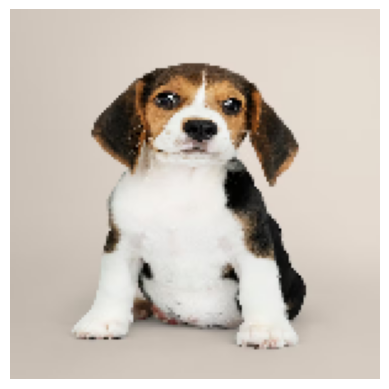

In [ ]:
# Importamos herramientas para trabajar con imágenes en Keras
from tensorflow.keras.preprocessing import image

# Obtenemos el nombre del archivo que el usuario subió
# uploaded es un diccionario → {nombre_archivo: datos}
img_path = list(uploaded.keys())[0]

# Cargamos la imagen desde el archivo
# target_size → redimensiona la imagen a (150x150)
img = image.load_img(img_path, target_size=(150,150))

# Convertimos la imagen a un arreglo numérico (pixeles)
img_array = image.img_to_array(img)

# Normalizamos los valores (de 0–255 a 0–1)
img_array = img_array / 255.0

# Agregamos una dimensión extra para que el modelo la acepte
# (1,150,150,3) → lote de 1 imagen
img_array = np.expand_dims(img_array, axis=0)

# El modelo hace la predicción
prediction = model.predict(img_array)


# Mostramos la imagen que el usuario subió
import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')


# Interpretamos el resultado
# > 0.5 → perro
# <= 0.5 → gato
if prediction[0] > 0.5:
    print("🐶 Es un PERRO")
else:
    print("🐱 Es un GATO")